# Heston Model Calibration

## Objective

This notebook studies the inverse problem of Heston model calibration.

Instead of specifying Heston parameters and computing option prices, calibration starts from observed option prices and estimates the parameter vector

$$
\boldsymbol{\psi}
=
(v_0,\kappa,\theta,\xi,\rho).
$$

The analysis begins with a synthetic market generated from known Heston parameters. This controlled experiment makes it possible to distinguish optimization and parameter-identification issues from model misspecification and market noise.

The calibration procedure is developed in four stages:

1. generate a synthetic option-price surface from known Heston parameters;
2. recover the parameters using bounded nonlinear least squares;
3. compare fitted prices and parameters with their true values;
4. investigate calibration stability using different initial guesses and noisy observations.

In [1]:
import sys
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CURRENT_DIR = Path.cwd().resolve()

if (CURRENT_DIR / "src").exists():
    PROJECT_ROOT = CURRENT_DIR

elif (CURRENT_DIR.parent / "src").exists():
    PROJECT_ROOT = CURRENT_DIR.parent

else:
    raise RuntimeError(
        "Could not locate the project root."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

FIGURE_DIR = (
    PROJECT_ROOT
    / "figures"
)

FIGURE_DIR.mkdir(
    exist_ok=True
)

from src.calibration.heston_calibration import (
    PARAMETER_NAMES,
    heston_call_price_vector,
    calibrate_heston,
)

from src.volatility.implied_volatility import (
    implied_volatility,
)

print("Project root:", PROJECT_ROOT)

Project root: /Users/amber/derivatives-pricing-calibration


## 1. Calibration as an Inverse Problem

Let the Heston parameter vector be

$$
\boldsymbol{\psi}
=
(v_0,\kappa,\theta,\xi,\rho).
$$

For each observed option $i$, the Heston model produces a price

$$
C_{\mathrm{Heston}}
(K_i,T_i;\boldsymbol{\psi}).
$$

Calibration estimates the parameter vector by minimizing the sum of squared pricing residuals:

$$
\hat{\boldsymbol{\psi}}
=
\arg\min_{\boldsymbol{\psi}\in\mathcal B}
\sum_{i=1}^{N}
\left[
C_{\mathrm{Heston}}
(K_i,T_i;\boldsymbol{\psi})
-
C_i^{\mathrm{obs}}
\right]^2.
$$

The set $\mathcal B$ represents economically and numerically admissible parameter bounds.

Because the objective is nonlinear in the Heston parameters, calibration may depend on the starting values, the option surface used, parameter interactions, and numerical pricing accuracy.

## 2. Synthetic Market Design

A synthetic option market is first generated from a known Heston parameter vector.

The true parameters are

$$
v_0=0.04,\qquad
\kappa=2.0,\qquad
\theta=0.04,\qquad
\xi=0.30,\qquad
\rho=-0.70.
$$

Since the synthetic prices are generated by the same Heston pricing model used in calibration, the true parameter vector provides a zero-pricing-error solution in the absence of numerical error.

This experiment therefore tests parameter recovery under controlled conditions.

In [2]:
S0 = 100.0
r = 0.05

true_parameters = np.array(
    [
        0.04,   # v0
        2.00,   # kappa
        0.04,   # theta
        0.30,   # xi
        -0.70,  # rho
    ],
    dtype=float,
)

true_parameter_dict = dict(
    zip(
        PARAMETER_NAMES,
        true_parameters,
    )
)

true_parameter_dict

{'v0': np.float64(0.04),
 'kappa': np.float64(2.0),
 'theta': np.float64(0.04),
 'xi': np.float64(0.3),
 'rho': np.float64(-0.7)}

In [3]:
strike_grid = np.array(
    [
        80.0,
        90.0,
        100.0,
        110.0,
        120.0,
    ]
)

maturity_grid = np.array(
    [
        0.25,
        0.50,
        1.00,
        2.00,
    ]
)

strikes = []
maturities = []

for maturity in maturity_grid:

    for strike in strike_grid:

        strikes.append(
            strike
        )

        maturities.append(
            maturity
        )

strikes = np.asarray(
    strikes,
    dtype=float,
)

maturities = np.asarray(
    maturities,
    dtype=float,
)

print(
    "Number of options:",
    len(strikes),
)

Number of options: 20


In [4]:
synthetic_market_prices = (
    heston_call_price_vector(
        parameters=true_parameters,
        S0=S0,
        r=r,
        strikes=strikes,
        maturities=maturities,
        integration_limit=100.0,
    )
)

synthetic_market_df = pd.DataFrame(
    {
        "Strike": strikes,
        "Maturity": maturities,
        "Market Price":
            synthetic_market_prices,
    }
)

synthetic_market_df[
    "Moneyness"
] = (
    synthetic_market_df["Strike"]
    / S0
)

synthetic_market_df

,Strike,Maturity,Market Price,Moneyness
0,80.0,0.25,21.104145,0.8
1,90.0,0.25,11.884365,0.9
2,100.0,0.25,4.587069,1.0
3,110.0,0.25,0.863393,1.1
4,120.0,0.25,0.053620,1.2
5,80.0,0.50,22.436161,0.8
6,90.0,0.50,13.817459,0.9
7,100.0,0.50,6.837200,1.0
8,110.0,0.50,2.384742,1.1
9,120.0,0.50,0.504430,1.2


In [5]:
price_surface = (
    synthetic_market_df
    .pivot(
        index="Maturity",
        columns="Strike",
        values="Market Price",
    )
)

price_surface

Strike,80.0,90.0,100.0,110.0,120.0
Maturity,,,,,
0.25,21.104145,11.884365,4.587069,0.863393,0.053620
0.50,22.436161,13.817459,6.837200,2.384742,0.504430
1.00,25.044557,17.075310,10.394219,5.430339,2.332633
2.00,29.672633,22.432681,16.142779,10.971768,6.991304


In [6]:
synthetic_ivs = []

for strike, maturity, price in zip(
    strikes,
    maturities,
    synthetic_market_prices,
):

    iv = implied_volatility(
        market_price=price,
        S=S0,
        K=float(strike),
        T=float(maturity),
        r=r,
        option_type="call",
    )

    synthetic_ivs.append(
        iv
    )

synthetic_market_df[
    "Implied Volatility"
] = synthetic_ivs

synthetic_market_df

,Strike,Maturity,Market Price,Moneyness,Implied Volatility
0,80.0,0.25,21.104145,0.8,0.244044
1,90.0,0.25,11.884365,0.9,0.221357
2,100.0,0.25,4.587069,1.0,0.198578
3,110.0,0.25,0.863393,1.1,0.176747
4,120.0,0.25,0.053620,1.2,0.160335
5,80.0,0.50,22.436161,0.8,0.238059
6,90.0,0.50,13.817459,0.9,0.217869
7,100.0,0.50,6.837200,1.0,0.198116
8,110.0,0.50,2.384742,1.1,0.179462
9,120.0,0.50,0.504430,1.2,0.163938


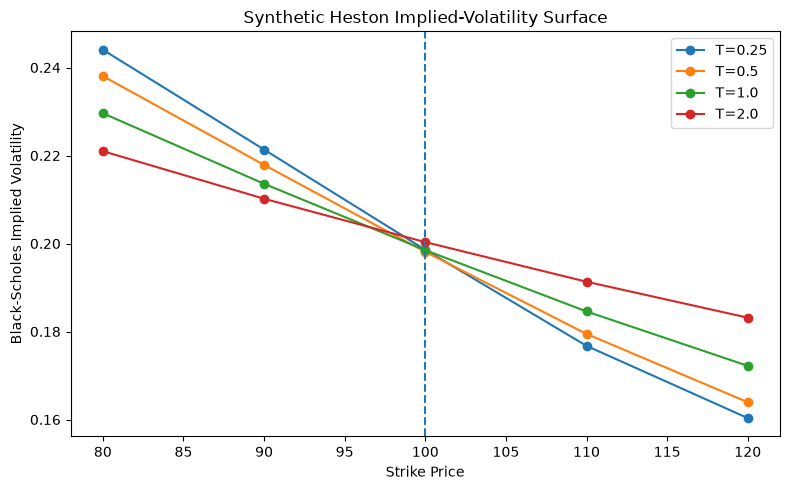

In [7]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

for maturity in maturity_grid:

    subset = synthetic_market_df[
        synthetic_market_df[
            "Maturity"
        ]
        == maturity
    ]

    ax.plot(
        subset["Strike"],
        subset[
            "Implied Volatility"
        ],
        marker="o",
        label=f"T={maturity}",
    )

ax.axvline(
    S0,
    linestyle="--",
)

ax.set_xlabel(
    "Strike Price"
)

ax.set_ylabel(
    "Black-Scholes Implied Volatility"
)

ax.set_title(
    "Synthetic Heston Implied-Volatility Surface"
)

ax.legend()

fig.tight_layout()

figure_path = (
    FIGURE_DIR
    / "heston_calibration_synthetic_iv.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [8]:
initial_guess = np.array(
    [
        0.07,
        1.20,
        0.06,
        0.50,
        -0.40,
    ],
    dtype=float,
)

initial_guess_dict = dict(
    zip(
        PARAMETER_NAMES,
        initial_guess,
    )
)

initial_guess_dict

{'v0': np.float64(0.07),
 'kappa': np.float64(1.2),
 'theta': np.float64(0.06),
 'xi': np.float64(0.5),
 'rho': np.float64(-0.4)}

## 3. Parameter Recovery from the Synthetic Surface

The calibration is intentionally initialized away from the true parameter vector.

If the optimization procedure and pricing engine are working correctly, the calibrated prices should approach the synthetic observations.

A stronger question is whether the optimizer also recovers the original Heston parameters themselves.

These two questions are different:

- **price fit:** can the calibrated model reproduce the option surface?
- **parameter recovery:** does the fitted surface uniquely identify the true parameter vector?

This distinction becomes important when studying calibration stability and parameter identifiability.

In [9]:
start_time = perf_counter()

calibration_result = (
    calibrate_heston(
        market_prices=(
            synthetic_market_prices
        ),
        S0=S0,
        r=r,
        strikes=strikes,
        maturities=maturities,
        initial_guess=(
            initial_guess
        ),
        integration_limit=100.0,
        max_nfev=250,
        verbose=1,
    )
)

elapsed_time = (
    perf_counter()
    - start_time
)

print(
    "Success:",
    calibration_result[
        "success"
    ],
)

print(
    "Message:",
    calibration_result[
        "message"
    ],
)

print(
    "Function evaluations:",
    calibration_result[
        "nfev"
    ],
)

print(
    "RMSE:",
    calibration_result[
        "rmse"
    ],
)

print(
    "MAE:",
    calibration_result[
        "mae"
    ],
)

print(
    "Elapsed seconds:",
    elapsed_time,
)

`gtol` termination condition is satisfied.
Function evaluations 12, initial cost 1.9506e+01, final cost 2.1383e-20, first-order optimality 2.03e-09.
Success: True
Message: `gtol` termination condition is satisfied.
Function evaluations: 12
RMSE: 4.6242290337981084e-11
MAE: 3.60137919486192e-11
Elapsed seconds: 2.3593134169932455


In [10]:
estimated_parameters = (
    calibration_result["x"]
)

parameter_comparison_df = (
    pd.DataFrame(
        {
            "Parameter":
                PARAMETER_NAMES,
            "True":
                true_parameters,
            "Initial Guess":
                initial_guess,
            "Estimated":
                estimated_parameters,
        }
    )
)

parameter_comparison_df[
    "Absolute Error"
] = np.abs(
    parameter_comparison_df[
        "Estimated"
    ]
    -
    parameter_comparison_df[
        "True"
    ]
)

parameter_comparison_df

,Parameter,True,Initial Guess,Estimated,Absolute Error
0,v0,0.04,0.07,0.04,9.329829e-13
1,kappa,2.00,1.20,2.00,2.547078e-10
2,theta,0.04,0.06,0.04,1.131803e-12
3,xi,0.30,0.50,0.30,1.551115e-10
4,rho,-0.70,-0.40,-0.70,3.271717e-10


In [11]:
fitted_prices = (
    calibration_result[
        "fitted_prices"
    ]
)

fit_df = (
    synthetic_market_df[
        [
            "Strike",
            "Maturity",
            "Market Price",
        ]
    ]
    .copy()
)

fit_df[
    "Fitted Price"
] = fitted_prices

fit_df[
    "Residual"
] = (
    fit_df["Fitted Price"]
    - fit_df["Market Price"]
)

fit_df[
    "Absolute Error"
] = np.abs(
    fit_df["Residual"]
)

fit_df

,Strike,Maturity,Market Price,Fitted Price,Residual,Absolute Error
0,80.0,0.25,21.104145,21.104145,2.081890e-11,2.081890e-11
1,90.0,0.25,11.884365,11.884365,2.917488e-11,2.917488e-11
2,100.0,0.25,4.587069,4.587069,-1.348610e-11,1.348610e-11
3,110.0,0.25,0.863393,0.863393,2.766143e-11,2.766143e-11
4,120.0,0.25,0.053620,0.053620,4.256373e-11,4.256373e-11
5,80.0,0.50,22.436161,22.436161,4.033041e-11,4.033041e-11
6,90.0,0.50,13.817459,13.817459,1.492140e-11,1.492140e-11
7,100.0,0.50,6.837200,6.837200,-4.763479e-11,4.763479e-11
8,110.0,0.50,2.384742,2.384742,-3.069545e-12,3.069545e-12
9,120.0,0.50,0.504430,0.504430,1.165894e-10,1.165894e-10


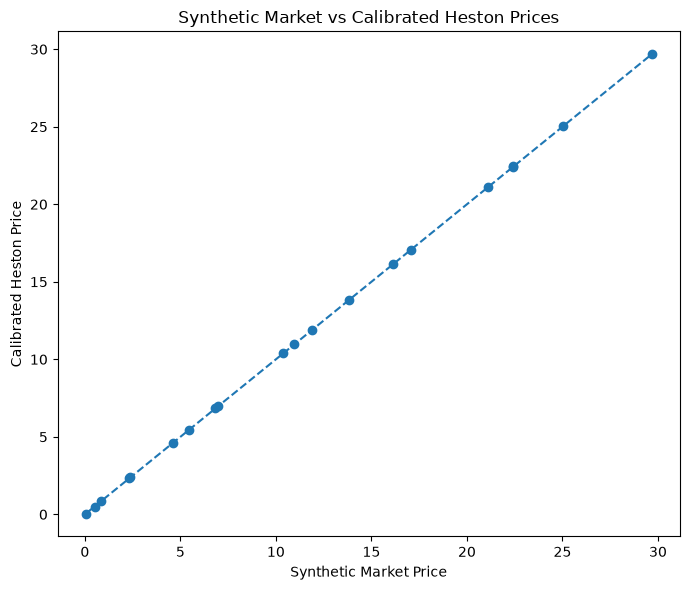

In [12]:
fig, ax = plt.subplots(
    figsize=(7, 6)
)

ax.scatter(
    fit_df["Market Price"],
    fit_df["Fitted Price"],
)

minimum_price = min(
    fit_df["Market Price"].min(),
    fit_df["Fitted Price"].min(),
)

maximum_price = max(
    fit_df["Market Price"].max(),
    fit_df["Fitted Price"].max(),
)

ax.plot(
    [
        minimum_price,
        maximum_price,
    ],
    [
        minimum_price,
        maximum_price,
    ],
    linestyle="--",
)

ax.set_xlabel(
    "Synthetic Market Price"
)

ax.set_ylabel(
    "Calibrated Heston Price"
)

ax.set_title(
    "Synthetic Market vs Calibrated Heston Prices"
)

fig.tight_layout()

figure_path = (
    FIGURE_DIR
    / "heston_calibration_price_fit.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

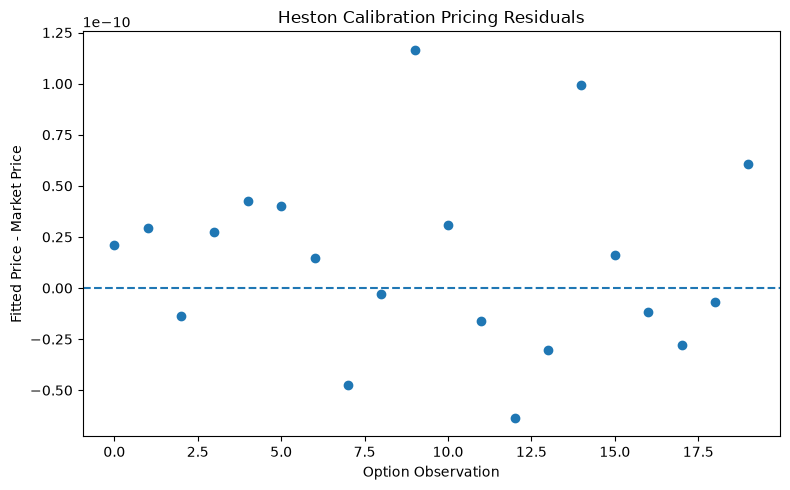

In [13]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.scatter(
    np.arange(
        len(fit_df)
    ),
    fit_df["Residual"],
)

ax.axhline(
    0.0,
    linestyle="--",
)

ax.set_xlabel(
    "Option Observation"
)

ax.set_ylabel(
    "Fitted Price - Market Price"
)

ax.set_title(
    "Heston Calibration Pricing Residuals"
)

fig.tight_layout()

figure_path = (
    FIGURE_DIR
    / "heston_calibration_residuals.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 4. Multiple-Start Calibration and Parameter Stability

A single successful calibration does not establish that the optimization problem is globally stable. Nonlinear least-squares problems may contain flat directions, strong parameter interactions, or multiple local minima.

To investigate optimization stability, the same synthetic Heston surface is calibrated from several deliberately different initial guesses. Because the synthetic data are noise-free and generated by the same pricing model, a stable calibration procedure should recover essentially the same price fit from each starting point. Parameter agreement across starts provides additional evidence about identifiability in this controlled experiment.


In [14]:
initial_guesses = {
    "A": np.array([0.07, 1.20, 0.06, 0.50, -0.40]),
    "B": np.array([0.02, 3.50, 0.03, 0.20, -0.85]),
    "C": np.array([0.10, 0.60, 0.08, 0.70, -0.20]),
    "D": np.array([0.03, 4.00, 0.03, 0.15, -0.85]),
    "E": np.array([0.08, 3.00, 0.10, 0.90, -0.55]),
}

multi_start_results = {}
multi_start_rows = []

for label, guess in initial_guesses.items():
    start_time = perf_counter()

    result = calibrate_heston(
        market_prices=synthetic_market_prices,
        S0=S0,
        r=r,
        strikes=strikes,
        maturities=maturities,
        initial_guess=guess,
        integration_limit=100.0,
        max_nfev=300,
        verbose=0,
    )

    elapsed = perf_counter() - start_time
    multi_start_results[label] = result

    row = {
        "Start": label,
        "Success": result["success"],
        "RMSE": result["rmse"],
        "MAE": result["mae"],
        "NFEV": result["nfev"],
        "Elapsed Seconds": elapsed,
    }

    for name, value in zip(PARAMETER_NAMES, result["x"]):
        row[name] = value

    row["Mean Absolute Relative Parameter Error"] = np.mean(
        np.abs(
            (result["x"] - true_parameters)
            / np.maximum(np.abs(true_parameters), 1e-12)
        )
    )

    multi_start_rows.append(row)

multi_start_df = pd.DataFrame(multi_start_rows)
multi_start_df


,Start,Success,RMSE,MAE,NFEV,Elapsed Seconds,v0,kappa,theta,xi,rho,Mean Absolute Relative Parameter Error
0,A,True,4.624229e-11,3.601379e-11,12,2.304111,0.04,2.0,0.04,0.3,-0.7,2.326800e-10
1,B,True,8.789158e-14,7.849277e-14,9,1.594808,0.04,2.0,0.04,0.3,-0.7,6.172615e-14
2,C,True,3.981774e-14,3.277378e-14,19,3.355259,0.04,2.0,0.04,0.3,-0.7,4.428792e-14
3,D,True,3.008346e-12,2.573919e-12,8,1.579390,0.04,2.0,0.04,0.3,-0.7,4.933879e-12
4,E,True,8.973767e-14,7.327472e-14,14,2.682242,0.04,2.0,0.04,0.3,-0.7,9.964714e-14


In [15]:
parameter_stability_df = multi_start_df[
    ["Start", *PARAMETER_NAMES, "RMSE", "NFEV"]
].copy()

parameter_stability_df


,Start,v0,kappa,theta,xi,rho,RMSE,NFEV
0,A,0.04,2.0,0.04,0.3,-0.7,4.624229e-11,12
1,B,0.04,2.0,0.04,0.3,-0.7,8.789158e-14,9
2,C,0.04,2.0,0.04,0.3,-0.7,3.981774e-14,19
3,D,0.04,2.0,0.04,0.3,-0.7,3.008346e-12,8
4,E,0.04,2.0,0.04,0.3,-0.7,8.973767e-14,14


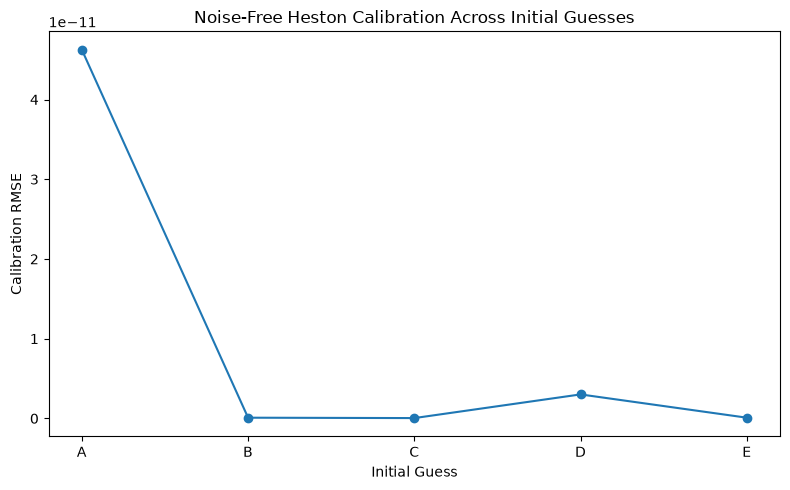

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    multi_start_df["Start"],
    multi_start_df["RMSE"],
    marker="o",
)

ax.set_xlabel("Initial Guess")
ax.set_ylabel("Calibration RMSE")
ax.set_title("Noise-Free Heston Calibration Across Initial Guesses")

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "heston_calibration_multistart_rmse.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


### Interpretation of the Multiple-Start Experiment

Two distinct questions should be evaluated jointly:

- **optimization stability:** do different starting values converge successfully and produce similarly small pricing errors?
- **parameter stability:** do those solutions also imply similar values of $v_0$, $\kappa$, $\theta$, $\xi$, and $\rho$?

If pricing RMSE is consistently tiny while parameter estimates differ materially, the surface can be well fitted without uniquely identifying the structural parameters. If both price fit and parameter estimates are stable, the controlled synthetic experiment provides stronger evidence of local parameter identification.


## 5. Local Identifiability Diagnostic

Multiple starts provide a global empirical stability check. A complementary local diagnostic can be obtained from the Jacobian of calibration residuals with respect to the parameters.

Because the Heston parameters have different numerical scales, the Jacobian columns are normalized before computing singular values. A very small final singular value, or a very large condition number, indicates that some parameter combinations have similar effects on option prices and are therefore difficult to distinguish locally.

This diagnostic is local and scale-sensitive; it should be interpreted together with the multiple-start results rather than as a standalone proof of identification.


In [17]:
def normalized_jacobian_diagnostics(calibration_output):
    jacobian = np.asarray(
        calibration_output["optimizer_result"].jac,
        dtype=float,
    )

    column_norms = np.linalg.norm(
        jacobian,
        axis=0,
    )

    safe_norms = np.where(
        column_norms > 0,
        column_norms,
        1.0,
    )

    normalized_jacobian = (
        jacobian
        / safe_norms
    )

    singular_values = np.linalg.svd(
        normalized_jacobian,
        compute_uv=False,
    )

    condition_number = (
        singular_values[0]
        / singular_values[-1]
    )

    return singular_values, condition_number

exact_singular_values, exact_condition_number = (
    normalized_jacobian_diagnostics(
        calibration_result
    )
)

print("Normalized Jacobian singular values:")
print(exact_singular_values)
print("Condition number:", exact_condition_number)


Normalized Jacobian singular values:
[1.91471934 1.01441107 0.49340145 0.21807105 0.11755877]
Condition number: 16.28733756328878


## 6. Noisy Synthetic Market

The previous experiment is deliberately idealized: the model used for calibration is exactly the model that generated the observations, and the synthetic prices contain no noise.

Real option data are less clean. Quotes contain bid-ask effects, asynchronous observations, microstructure noise, and model misspecification. To create a controlled but more realistic stress test, small reproducible perturbations are added to the synthetic **implied volatilities** and then converted back into Black-Scholes call prices.

Perturbing implied volatilities rather than raw option prices ensures that each individual synthetic quote remains consistent with a positive volatility input. The resulting surface should still be interpreted as a calibration stress test rather than as a fully arbitrage-clean market dataset.


In [18]:
from src.models.black_scholes import call_price

rng = np.random.default_rng(20260907)

exact_ivs = np.asarray(
    synthetic_market_df["Implied Volatility"],
    dtype=float,
)

iv_noise = rng.normal(
    loc=0.0,
    scale=0.003,
    size=len(exact_ivs),
)

noisy_ivs = np.maximum(
    exact_ivs + iv_noise,
    0.01,
)

noisy_market_prices = np.array(
    [
        call_price(
            S0,
            float(strike),
            float(maturity),
            r,
            float(iv),
        )
        for strike, maturity, iv in zip(
            strikes,
            maturities,
            noisy_ivs,
        )
    ],
    dtype=float,
)

noisy_market_df = synthetic_market_df.copy()
noisy_market_df["Exact IV"] = exact_ivs
noisy_market_df["Noisy IV"] = noisy_ivs
noisy_market_df["IV Noise"] = iv_noise
noisy_market_df["Exact Heston Price"] = synthetic_market_prices
noisy_market_df["Noisy Market Price"] = noisy_market_prices

noisy_market_df[
    [
        "Strike",
        "Maturity",
        "Exact IV",
        "Noisy IV",
        "Exact Heston Price",
        "Noisy Market Price",
    ]
]


,Strike,Maturity,Exact IV,Noisy IV,Exact Heston Price,Noisy Market Price
0,80.0,0.25,0.244044,0.245892,21.104145,21.109286
1,90.0,0.25,0.221357,0.219096,11.884365,11.860424
2,100.0,0.25,0.198578,0.191148,4.587069,4.441161
3,110.0,0.25,0.176747,0.173971,0.863393,0.826487
4,120.0,0.25,0.160335,0.160584,0.053620,0.054196
5,80.0,0.50,0.238059,0.237853,22.436161,22.434431
6,90.0,0.50,0.217869,0.218800,13.817459,13.834632
7,100.0,0.50,0.198116,0.198119,6.837200,6.837282
8,110.0,0.50,0.179462,0.177560,2.384742,2.337255
9,120.0,0.50,0.163938,0.163615,0.504430,0.500511


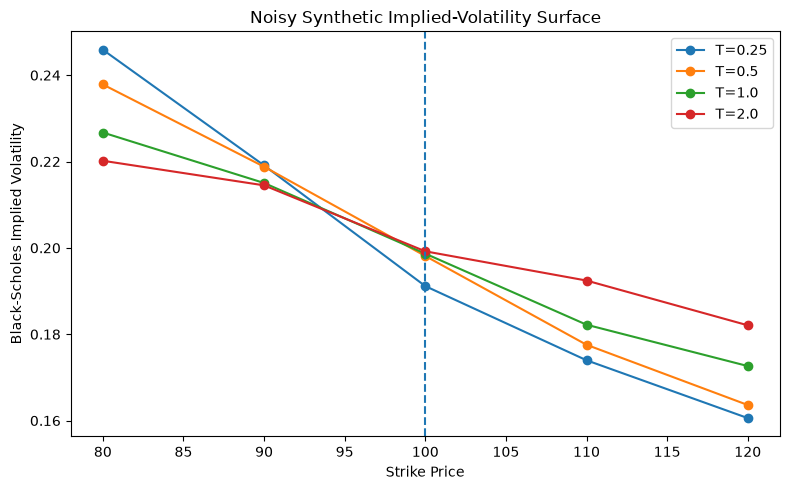

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

for maturity in maturity_grid:
    subset = noisy_market_df[
        noisy_market_df["Maturity"] == maturity
    ]

    ax.plot(
        subset["Strike"],
        subset["Noisy IV"],
        marker="o",
        label=f"T={maturity}",
    )

ax.axvline(S0, linestyle="--")
ax.set_xlabel("Strike Price")
ax.set_ylabel("Black-Scholes Implied Volatility")
ax.set_title("Noisy Synthetic Implied-Volatility Surface")
ax.legend()

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "heston_calibration_noisy_iv.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


## 7. Multiple-Start Calibration on Noisy Data

The noisy surface no longer lies exactly on the original Heston surface. Calibration must therefore trade off pricing errors across observations.

Repeating the optimization from multiple initial guesses now tests both optimizer robustness and the stability of parameter estimates when observations are imperfect.


In [20]:
noisy_multi_start_results = {}
noisy_multi_start_rows = []

for label, guess in initial_guesses.items():
    start_time = perf_counter()

    result = calibrate_heston(
        market_prices=noisy_market_prices,
        S0=S0,
        r=r,
        strikes=strikes,
        maturities=maturities,
        initial_guess=guess,
        integration_limit=100.0,
        max_nfev=350,
        verbose=0,
    )

    elapsed = perf_counter() - start_time
    noisy_multi_start_results[label] = result

    row = {
        "Start": label,
        "Success": result["success"],
        "RMSE": result["rmse"],
        "MAE": result["mae"],
        "NFEV": result["nfev"],
        "Elapsed Seconds": elapsed,
    }

    for name, value in zip(PARAMETER_NAMES, result["x"]):
        row[name] = value

    row["Mean Absolute Relative Parameter Error"] = np.mean(
        np.abs(
            (result["x"] - true_parameters)
            / np.maximum(np.abs(true_parameters), 1e-12)
        )
    )

    noisy_multi_start_rows.append(row)

noisy_multi_start_df = pd.DataFrame(noisy_multi_start_rows)
noisy_multi_start_df


,Start,Success,RMSE,MAE,NFEV,Elapsed Seconds,v0,kappa,theta,xi,rho,Mean Absolute Relative Parameter Error
0,A,True,0.053773,0.041975,12,2.212923,0.038484,1.710831,0.041346,0.301634,-0.672456,0.052185
1,B,True,0.053773,0.041975,10,1.756759,0.038484,1.710823,0.041346,0.301634,-0.672454,0.052186
2,C,True,0.053773,0.041975,19,3.387056,0.038484,1.710823,0.041346,0.301634,-0.672453,0.052187
3,D,True,0.053773,0.041975,10,1.687505,0.038484,1.710833,0.041346,0.301635,-0.672453,0.052186
4,E,True,0.053773,0.041975,19,3.136274,0.038484,1.710827,0.041346,0.301634,-0.672454,0.052186


In [21]:
best_noisy_index = noisy_multi_start_df["RMSE"].idxmin()
best_noisy_row = noisy_multi_start_df.loc[best_noisy_index]
best_noisy_label = best_noisy_row["Start"]
best_noisy_result = noisy_multi_start_results[best_noisy_label]

print("Best noisy calibration start:", best_noisy_label)
print("Best noisy RMSE:", best_noisy_result["rmse"])
print("Best noisy MAE:", best_noisy_result["mae"])
print("Best noisy parameters:")

best_noisy_parameter_df = pd.DataFrame(
    {
        "Parameter": PARAMETER_NAMES,
        "True": true_parameters,
        "Estimated": best_noisy_result["x"],
    }
)

best_noisy_parameter_df["Absolute Error"] = np.abs(
    best_noisy_parameter_df["Estimated"]
    - best_noisy_parameter_df["True"]
)

best_noisy_parameter_df


Best noisy calibration start: D
Best noisy RMSE: 0.053773085857833525
Best noisy MAE: 0.041975089764070696
Best noisy parameters:


,Parameter,True,Estimated,Absolute Error
0,v0,0.04,0.038484,0.001516
1,kappa,2.00,1.710833,0.289167
2,theta,0.04,0.041346,0.001346
3,xi,0.30,0.301635,0.001635
4,rho,-0.70,-0.672453,0.027547


In [22]:
parameter_ranges = []

for name in PARAMETER_NAMES:
    values = noisy_multi_start_df[name]
    parameter_ranges.append(
        {
            "Parameter": name,
            "Minimum Estimate": values.min(),
            "Maximum Estimate": values.max(),
            "Range Across Starts": values.max() - values.min(),
            "True Value": true_parameter_dict[name],
        }
    )

noisy_parameter_range_df = pd.DataFrame(parameter_ranges)
noisy_parameter_range_df


,Parameter,Minimum Estimate,Maximum Estimate,Range Across Starts,True Value
0,v0,0.038484,0.038484,1.413383e-08,0.04
1,kappa,1.710823,1.710833,1.026288e-05,2.00
2,theta,0.041346,0.041346,2.440719e-08,0.04
3,xi,0.301634,0.301635,1.383429e-06,0.30
4,rho,-0.672456,-0.672453,2.656908e-06,-0.70


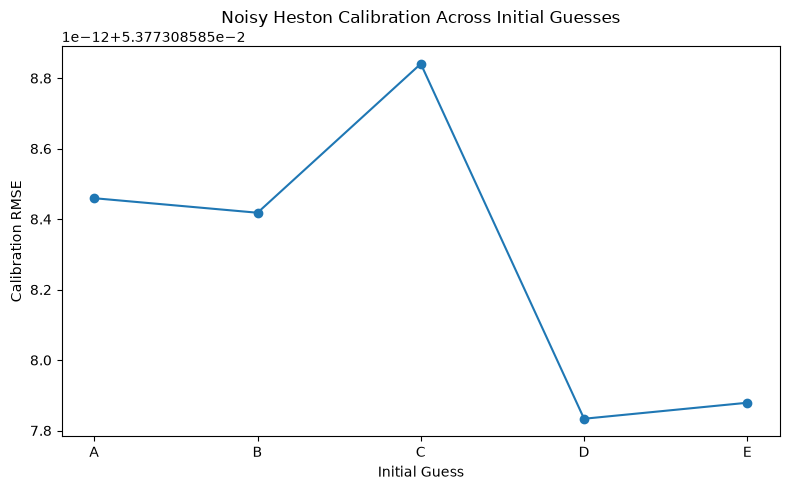

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    noisy_multi_start_df["Start"],
    noisy_multi_start_df["RMSE"],
    marker="o",
)

ax.set_xlabel("Initial Guess")
ax.set_ylabel("Calibration RMSE")
ax.set_title("Noisy Heston Calibration Across Initial Guesses")

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "heston_calibration_noisy_multistart_rmse.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


### Price Fit versus Parameter Recovery

The noisy calibration should be interpreted using both the pricing error and the spread of parameter estimates across starts.

A small RMSE demonstrates that the fitted Heston surface reproduces the noisy observations well. It does **not** automatically imply that the underlying structural parameters are recovered precisely. Noise can shift the optimum, and correlated parameter effects can allow different parameter vectors to produce similar option prices.

This distinction is central to calibration problems: **good fit is not the same as unique identification**.


## 8. Noisy-Surface Pricing and Implied-Volatility Diagnostics

The best noisy calibration is now evaluated observation by observation. Pricing residuals show where the Heston model misses the noisy quotes in price space, while implied-volatility residuals express the same discrepancies in the volatility representation used by option markets.


In [24]:
noisy_fitted_prices = np.asarray(
    best_noisy_result["fitted_prices"],
    dtype=float,
)

noisy_fitted_ivs = []

for strike, maturity, fitted_price in zip(
    strikes,
    maturities,
    noisy_fitted_prices,
):
    noisy_fitted_ivs.append(
        implied_volatility(
            market_price=float(fitted_price),
            S=S0,
            K=float(strike),
            T=float(maturity),
            r=r,
            option_type="call",
        )
    )

noisy_fitted_ivs = np.asarray(noisy_fitted_ivs)

noisy_fit_df = pd.DataFrame(
    {
        "Strike": strikes,
        "Maturity": maturities,
        "Noisy Market Price": noisy_market_prices,
        "Fitted Price": noisy_fitted_prices,
        "Price Residual": noisy_fitted_prices - noisy_market_prices,
        "Noisy Market IV": noisy_ivs,
        "Fitted IV": noisy_fitted_ivs,
        "IV Residual": noisy_fitted_ivs - noisy_ivs,
    }
)

noisy_fit_df


,Strike,Maturity,Noisy Market Price,Fitted Price,Price Residual,Noisy Market IV,Fitted IV,IV Residual
0,80.0,0.25,21.109286,21.098136,-0.011150,0.245892,0.241814,-0.004078
1,90.0,0.25,11.860424,11.858232,-0.002192,0.219096,0.218888,-0.000208
2,100.0,0.25,4.441161,4.535196,0.094035,0.191148,0.195937,0.004789
3,110.0,0.25,0.826487,0.832747,0.006259,0.173971,0.174445,0.000474
4,120.0,0.25,0.054196,0.052158,-0.002037,0.160584,0.159694,-0.000890
5,80.0,0.50,22.434431,22.428321,-0.006109,0.237853,0.237120,-0.000733
6,90.0,0.50,13.834632,13.792136,-0.042495,0.218800,0.216491,-0.002309
7,100.0,0.50,6.837282,6.788447,-0.048835,0.198119,0.196334,-0.001786
8,110.0,0.50,2.337255,2.337975,0.000720,0.177560,0.177589,0.000029
9,120.0,0.50,0.500511,0.491798,-0.008714,0.163615,0.162891,-0.000724


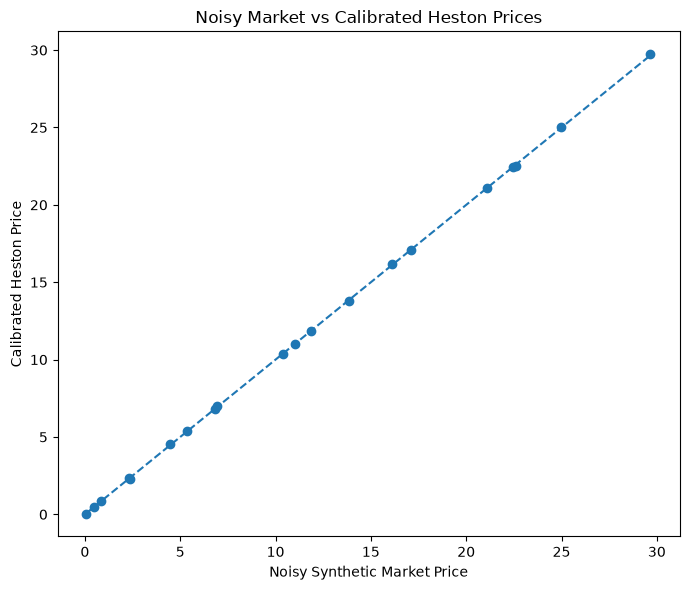

In [25]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    noisy_fit_df["Noisy Market Price"],
    noisy_fit_df["Fitted Price"],
)

minimum_price = min(
    noisy_fit_df["Noisy Market Price"].min(),
    noisy_fit_df["Fitted Price"].min(),
)

maximum_price = max(
    noisy_fit_df["Noisy Market Price"].max(),
    noisy_fit_df["Fitted Price"].max(),
)

ax.plot(
    [minimum_price, maximum_price],
    [minimum_price, maximum_price],
    linestyle="--",
)

ax.set_xlabel("Noisy Synthetic Market Price")
ax.set_ylabel("Calibrated Heston Price")
ax.set_title("Noisy Market vs Calibrated Heston Prices")

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "heston_calibration_noisy_price_fit.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


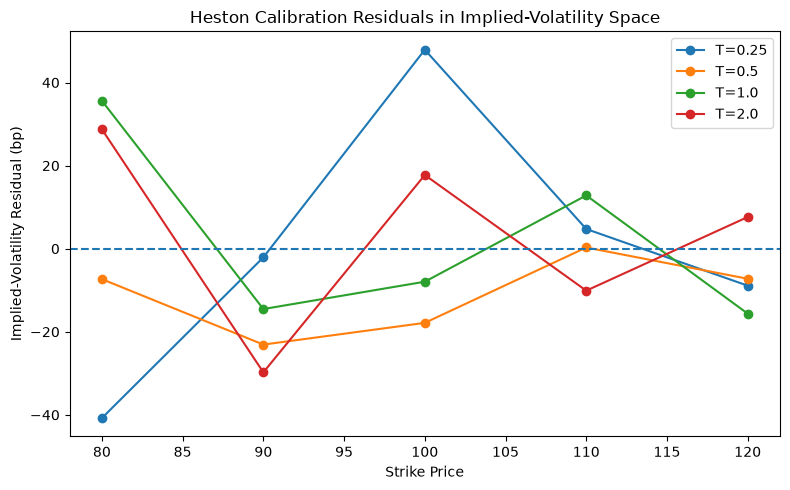

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

for maturity in maturity_grid:
    subset = noisy_fit_df[
        noisy_fit_df["Maturity"] == maturity
    ]

    ax.plot(
        subset["Strike"],
        subset["IV Residual"] * 10_000,
        marker="o",
        label=f"T={maturity}",
    )

ax.axhline(0.0, linestyle="--")
ax.set_xlabel("Strike Price")
ax.set_ylabel("Implied-Volatility Residual (bp)")
ax.set_title("Heston Calibration Residuals in Implied-Volatility Space")
ax.legend()

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "heston_calibration_noisy_iv_residuals.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


## 9. Local Identifiability after Adding Noise

The normalized Jacobian diagnostic is repeated for the best noisy calibration. Comparing its singular values with the noise-free case helps determine whether the local inverse problem becomes less sharply identified once the observations no longer lie exactly on the model surface.


In [27]:
noisy_singular_values, noisy_condition_number = (
    normalized_jacobian_diagnostics(
        best_noisy_result
    )
)

identifiability_df = pd.DataFrame(
    {
        "Noise-Free Singular Value": exact_singular_values,
        "Noisy Singular Value": noisy_singular_values,
    }
)

print("Noise-free normalized condition number:", exact_condition_number)
print("Noisy normalized condition number:", noisy_condition_number)

identifiability_df


Noise-free normalized condition number: 16.28733756328878
Noisy normalized condition number: 16.153278789162776


,Noise-Free Singular Value,Noisy Singular Value
0,1.914719,1.938831
1,1.014411,0.976944
2,0.493401,0.483901
3,0.218071,0.194799
4,0.117559,0.120027


## 10. Export of Calibration Diagnostics

The main calibration tables are saved as CSV files so that the numerical results can be inspected independently of the notebook and reused in later model-comparison work.


In [28]:
DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)

multi_start_df.to_csv(
    DATA_DIR / "heston_calibration_multistart.csv",
    index=False,
)

noisy_multi_start_df.to_csv(
    DATA_DIR / "heston_noisy_calibration_multistart.csv",
    index=False,
)

noisy_fit_df.to_csv(
    DATA_DIR / "heston_noisy_calibration_fit.csv",
    index=False,
)

print("Saved calibration diagnostics to:", DATA_DIR)


Saved calibration diagnostics to: /Users/amber/derivatives-pricing-calibration/data


## 11. Conclusion

This notebook formulated Heston calibration as a nonlinear inverse problem and evaluated the calibration pipeline under both idealized and noisy synthetic conditions.

The noise-free synthetic experiment first verified whether the calibration engine could recover a surface generated from known Heston parameters. Multiple initial guesses were then used to distinguish a one-off optimization success from broader calibration stability.

A second experiment perturbed the synthetic implied-volatility surface before converting the observations back into option prices. This produced a controlled setting in which the fitted Heston model could no longer reproduce every quote exactly. The noisy experiment therefore separated **price-fitting quality** from **parameter-recovery quality** and highlighted the importance of parameter stability across starting values.

Local Jacobian singular-value diagnostics complemented the multiple-start analysis by measuring how distinctly the option surface responds to different parameter directions near the optimum. These diagnostics should be interpreted cautiously because identifiability depends on the option grid, parameter scaling, observation noise, and calibration objective.

The main methodological lesson is that a small calibration error is not sufficient evidence of a uniquely determined structural model. A credible calibration analysis should examine pricing residuals, parameter sensitivity, multiple initializations, numerical stability, and the effect of noisy observations together.

The next stage of the project can extend this framework to model comparison and, when appropriate, real option-market data. At that point the central distinction becomes especially important:

- **numerical error** arises from simulation, discretization, integration, and optimization;
- **model error** arises when even a well-calibrated model cannot reproduce systematic features of observed option prices or implied-volatility surfaces.
